In [24]:
gid_map = {
    'scalability': '1513474150',
    'optimality': '2117154112',
    'profiling_agg': '1122559114',
    'cpu_performance_agg': '811081730'
}

In [25]:
import gdown
import pandas as pd
import numpy as np
from scipy import stats

sheet_id = "1WUywPr_TxlUfPGVyMF0I2ALxXiHAyknKoZ3X13kKrUI"

def get_pandas_from_gid(gid_name):
    # Replace with your actual Google Sheet ID
    # Optionally: specify the sheet/tab number (gid=0 for the first sheet)
    gid = gid_map[gid_name]
    
    # Construct export URL
    url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"
    
    # Set desired output filename
    output = f"{gid_name}.csv"
    
    # Download CSV using gdown
    gdown.download(url, output, quiet=False)
    original_df = pd.read_csv(output)
    return original_df

In [26]:
df_raw = get_pandas_from_gid('cpu_performance_agg')
df_raw

/home/viniciusvdias/miniconda3/lib/python3.11/site-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=None
  warnings.warn(
Downloading...
From: https://docs.google.com/spreadsheets/d/1WUywPr_TxlUfPGVyMF0I2ALxXiHAyknKoZ3X13kKrUI/export?format=csv&gid=811081730
To: /home/viniciusvdias/repos/fractal-private/plots/cpu_performance_agg.csv
2.61kB [00:00, 2.77MB/s]


,obj_function,graph,AVERAGE of cpu_core_topdown_retiring_perc,STDEV of cpu_core_topdown_retiring_perc,AVERAGE of cpu_core_topdown_bad_spec_perc,STDEV of cpu_core_topdown_bad_spec_perc,AVERAGE of cpu_core_topdown_fe_bound_perc,STDEV of cpu_core_topdown_fe_bound_perc,AVERAGE of cpu_core_topdown_be_bound_perc,STDEV of cpu_core_topdown_be_bound_perc,...,STDEV of cpu_core_topdown_mem_bound_core_bound_perc,AVERAGE of cpu_core_topdown_mem_bound_perc,STDEV of cpu_core_topdown_mem_bound_perc,Unnamed: 15,retiring_confidence_interval,badspec_confidence_interval,febound_confidence_interval,bebound_confidence_interval,core_bound_confidence_interval,mem_bound_confidence_interval
0,conductance,citeseer,48.26,3.27,9.96,0.59,14.10,2.13,27.68,2.86,...,1.80,17.20,2.61,NaN,1.22,0.22,0.79,1.07,0.67,0.97
1,conductance,patents,49.02,3.33,13.53,1.17,11.71,1.21,25.73,2.02,...,1.20,10.30,2.16,NaN,1.24,0.44,0.45,0.75,0.45,0.81
2,conductance,youtube,40.85,3.33,22.13,1.61,14.25,2.29,22.77,2.86,...,0.65,11.13,2.76,NaN,1.24,0.60,0.85,1.07,0.24,1.03
3,degreeentropy,citeseer,44.75,5.94,9.78,2.60,12.02,3.86,33.44,2.65,...,1.17,20.90,2.22,NaN,2.22,0.97,1.44,0.99,0.44,0.83
4,degreeentropy,patents,57.26,6.71,11.61,1.50,12.78,2.71,18.36,2.87,...,0.93,9.24,2.62,NaN,2.50,0.56,1.01,1.07,0.35,0.98
5,degreeentropy,youtube,52.73,6.39,15.28,0.98,13.87,2.57,18.13,4.10,...,0.87,10.17,3.66,NaN,2.39,0.37,0.96,1.53,0.32,1.37
6,densesubgraph,citeseer,23.92,1.58,14.91,1.44,13.96,1.90,47.21,4.08,...,0.62,35.54,3.82,NaN,0.59,0.54,0.71,1.52,0.23,1.43
7,densesubgraph,patents,24.66,1.08,31.70,3.91,15.70,1.26,27.95,3.93,...,0.27,18.54,4.03,NaN,0.40,1.46,0.47,1.47,0.10,1.50
8,densesubgraph,youtube,24.98,0.77,34.21,2.64,15.71,0.80,25.10,2.16,...,0.28,16.17,2.03,NaN,0.29,0.99,0.30,0.81,0.11,0.76
9,labelentropy,citeseer,45.32,2.39,11.78,0.87,13.67,1.39,29.25,1.77,...,1.54,17.87,1.43,NaN,0.89,0.32,0.52,0.66,0.57,0.54


In [27]:
df = df_raw.copy()

df['obj_function'] = df['obj_function'].replace({
    'conductance': 'CO',
    'triangledensestsubgraph': 'TDS',
    'densesubgraph': 'DS',
    'degreeentropy': 'DE',
    'labelentropy': 'LE'
})

df['graph'] = df['graph'].replace({
    'citeseer': 'Citeseer',
    'patents': 'Patents',
    'youtube': 'Youtube'
})

new_names = {
    'AVERAGE of cpu_core_topdown_retiring_perc': 'retiring',
    'AVERAGE of cpu_core_topdown_bad_spec_perc': 'badspec',
    'AVERAGE of cpu_core_topdown_fe_bound_perc': 'febound',
    'AVERAGE of cpu_core_topdown_be_bound_perc': 'bebound',
    'AVERAGE of cpu_core_topdown_mem_bound_core_bound_perc': 'core_bound',
    'AVERAGE of cpu_core_topdown_mem_bound_perc': 'mem_bound',
}

df = df.rename(columns=new_names)

df.columns

Index(['obj_function', 'graph', 'retiring',
       'STDEV of cpu_core_topdown_retiring_perc', 'badspec',
       'STDEV of cpu_core_topdown_bad_spec_perc', 'febound',
       'STDEV of cpu_core_topdown_fe_bound_perc', 'bebound',
       'STDEV of cpu_core_topdown_be_bound_perc',
       'COUNT of cpu_core_topdown_retiring_perc', 'core_bound',
       'STDEV of cpu_core_topdown_mem_bound_core_bound_perc', 'mem_bound',
       'STDEV of cpu_core_topdown_mem_bound_perc', 'Unnamed: 15',
       'retiring_confidence_interval', 'badspec_confidence_interval',
       'febound_confidence_interval', 'bebound_confidence_interval',
       'core_bound_confidence_interval', 'mem_bound_confidence_interval'],
      dtype='object')

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.5  # previous pdf hatch linewidth

def plot_average_by_group_and_initial_solutions(df: pd.DataFrame, grouping_columns: list, value_column: str, ci_column: str, ylabel: str, title: str, yrange = range(0, 61, 10)):
    axis_fontsize = 35
    axis_title_fontsize = 35
    title_fontsize = 35
    legend_fontsize = 35
    hatches = ['/', '\\', '|', '-', '+', 'x', 'o', '.', '*']
    
    # Sort for consistent plotting: first by grouping_columns, then by graph
    df = df.sort_values(by=grouping_columns + ['graph'])

    plt.figure(figsize=(18, 9)) # Adjust figure size for potentially more x-axis labels

    # Get unique 'objective functions' for legend and bar differentiation
    unique_graphs = sorted(df['graph'].unique())
    num_graphs = len(unique_graphs)

    # Calculate the number of distinct groups for the X-axis
    # Create a string representation for each group for x-axis labels
    df['Group_Label'] = df[grouping_columns].apply(
        lambda row: " | ".join([f"{row[col]}" for col in grouping_columns]), axis=1
    )
    unique_groups = df['Group_Label'].unique()
    x_axis_positions = np.arange(len(unique_groups)) # Numerical positions for each group

    # Define bar width and spacing
    bar_width = 0.8 / num_graphs if num_graphs > 0 else 0.8
    
    # Generate a distinct color for each 'Initial Solution' value
    colors = mpl.colormaps.get_cmap('Pastel1')
    
    # Iterate through each unique 'Initial Solution' value to plot its bars
    for i, graph in enumerate(unique_graphs):
        # Filter data for the current 'Initial Solution' count
        subset_df = df[df['graph'] == graph].copy()
        
        # Merge with all unique groups to ensure all x-axis positions are covered, even if no data
        full_x_data = pd.DataFrame({'Group_Label': unique_groups})
        subset_df = pd.merge(full_x_data, subset_df, on='Group_Label', how='left')
        
        # Sort again to match the order of x_axis_positions
        subset_df = subset_df.set_index('Group_Label').loc[unique_groups].reset_index()

        # Calculate the x-position for bars of this 'graph'
        offset = (i - num_graphs / 2 + 0.5) * bar_width
        x_positions_for_bars = x_axis_positions + offset
        
        # Plot the bars
        plt.bar(
            x_positions_for_bars,
            subset_df[value_column],
            yerr=subset_df[ci_column],
            width=bar_width,
            capsize=5,
            label=f'{graph}', # Label for the legend
            color=colors(i),
            hatch=hatches[i],
            edgecolor='black',
            linewidth=0.8,
            error_kw=dict(lw=1.5, capsize=5, capthick=1.5)            
        )

    plt.ylabel(ylabel, fontsize=axis_title_fontsize)
    
    plt.xticks(x_axis_positions, unique_groups, rotation=0, ha='center', fontsize=axis_fontsize)
    plt.yticks(yrange, fontsize=axis_fontsize)
    
    plt.grid(True, linestyle='--', alpha=0.7, which="major", axis='y')
    plt.grid(False, axis='x')

    # Place legend outside the plot area, with title for initial solutions
    plt.legend(loc='best', borderaxespad=0., fontsize=legend_fontsize)
    
    plt.tight_layout()
    plt.savefig(title.replace(' ','_') + '.pdf')
    plt.show()

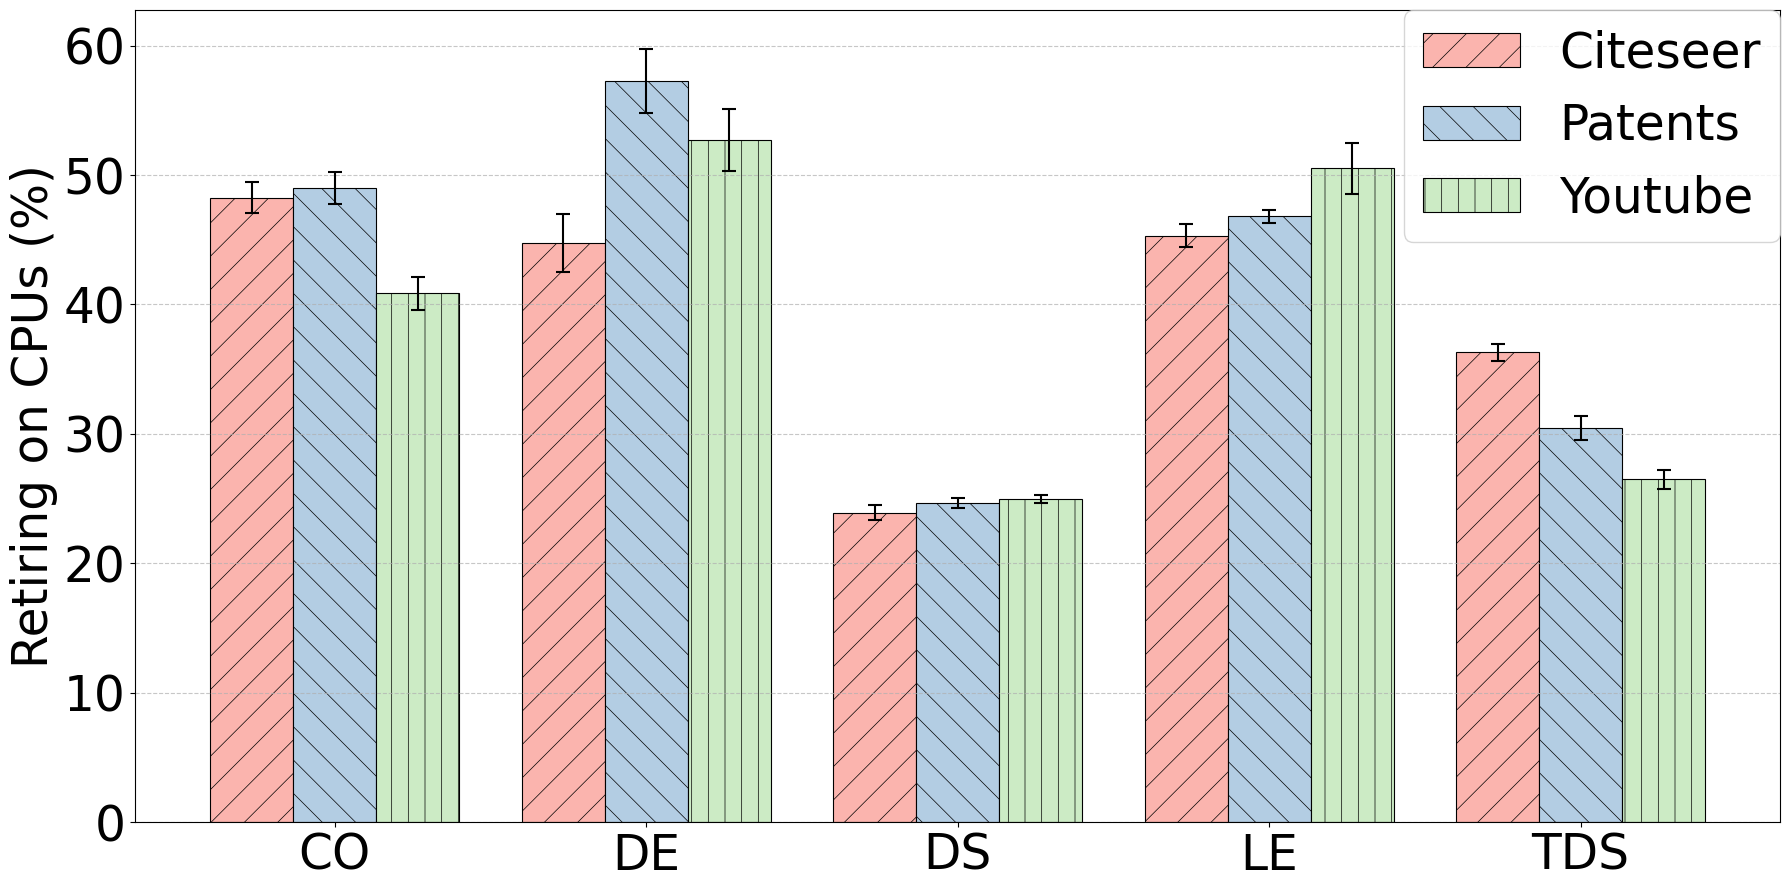

In [29]:
grouping_columns = ['obj_function']
plot_average_by_group_and_initial_solutions(df, grouping_columns, 'retiring', 'retiring_confidence_interval', 'Retiring on CPUs (%)', 'TMA Analysis Retiring')

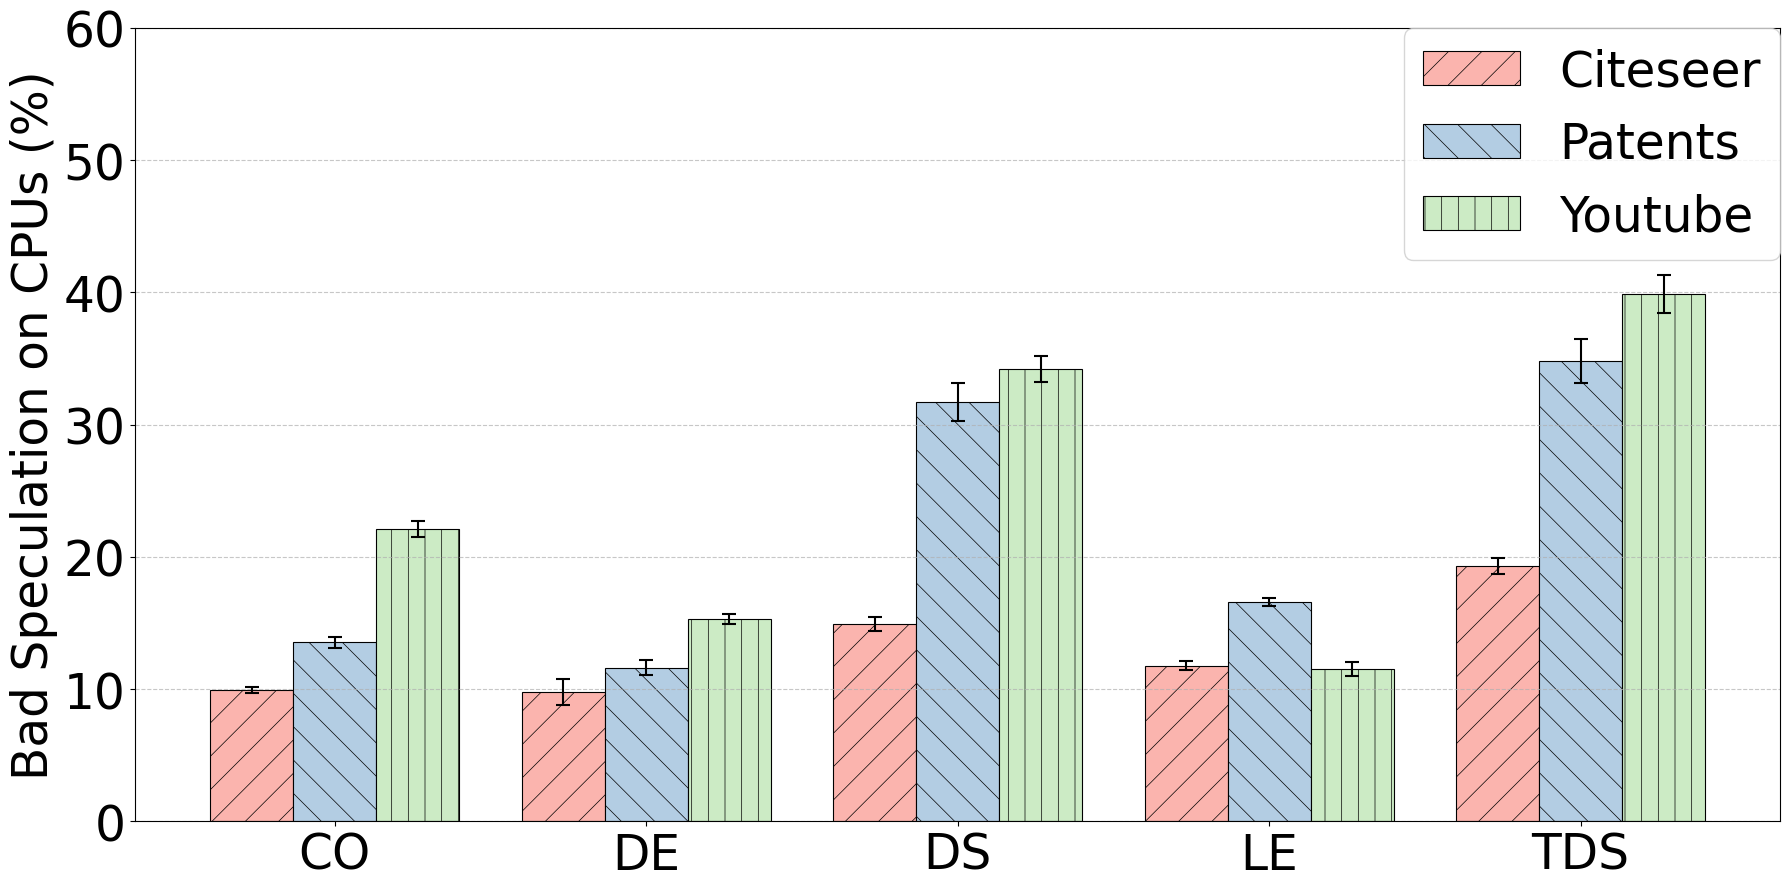

In [30]:
grouping_columns = ['obj_function']
plot_average_by_group_and_initial_solutions(df, grouping_columns, 'badspec', 'badspec_confidence_interval', 'Bad Speculation on CPUs (%)', 'TMA Analysis Bad Speculation')

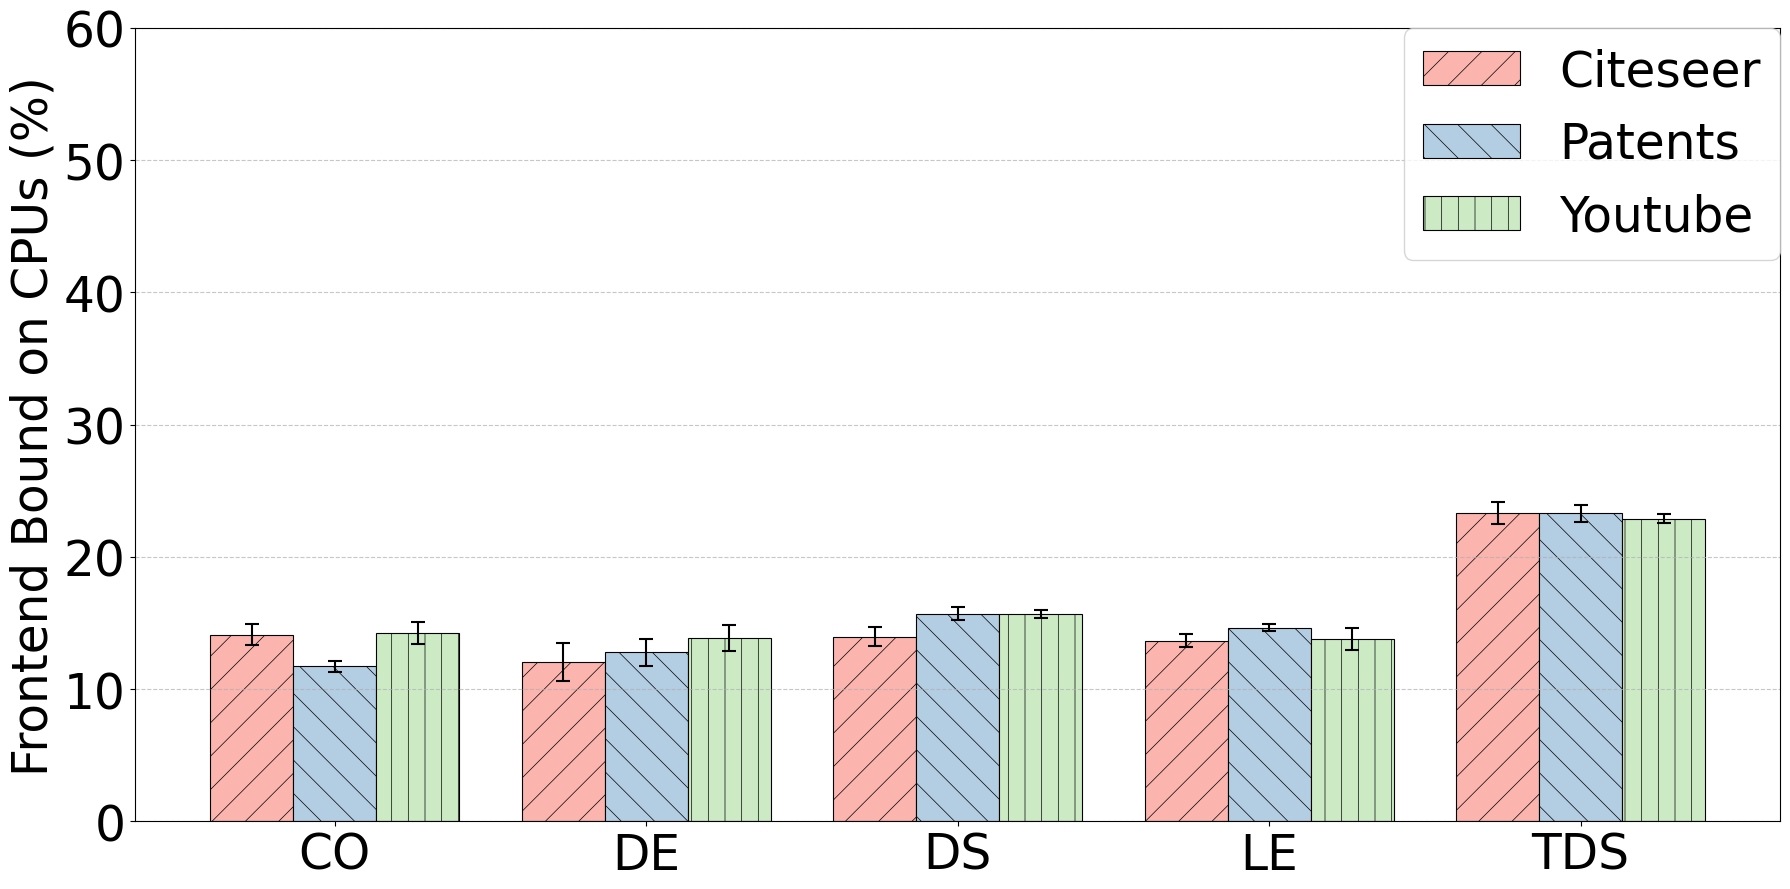

In [31]:
grouping_columns = ['obj_function']
plot_average_by_group_and_initial_solutions(df, grouping_columns, 'febound', 'febound_confidence_interval', 'Frontend Bound on CPUs (%)', 'TMA Analysis Frontend Bound')

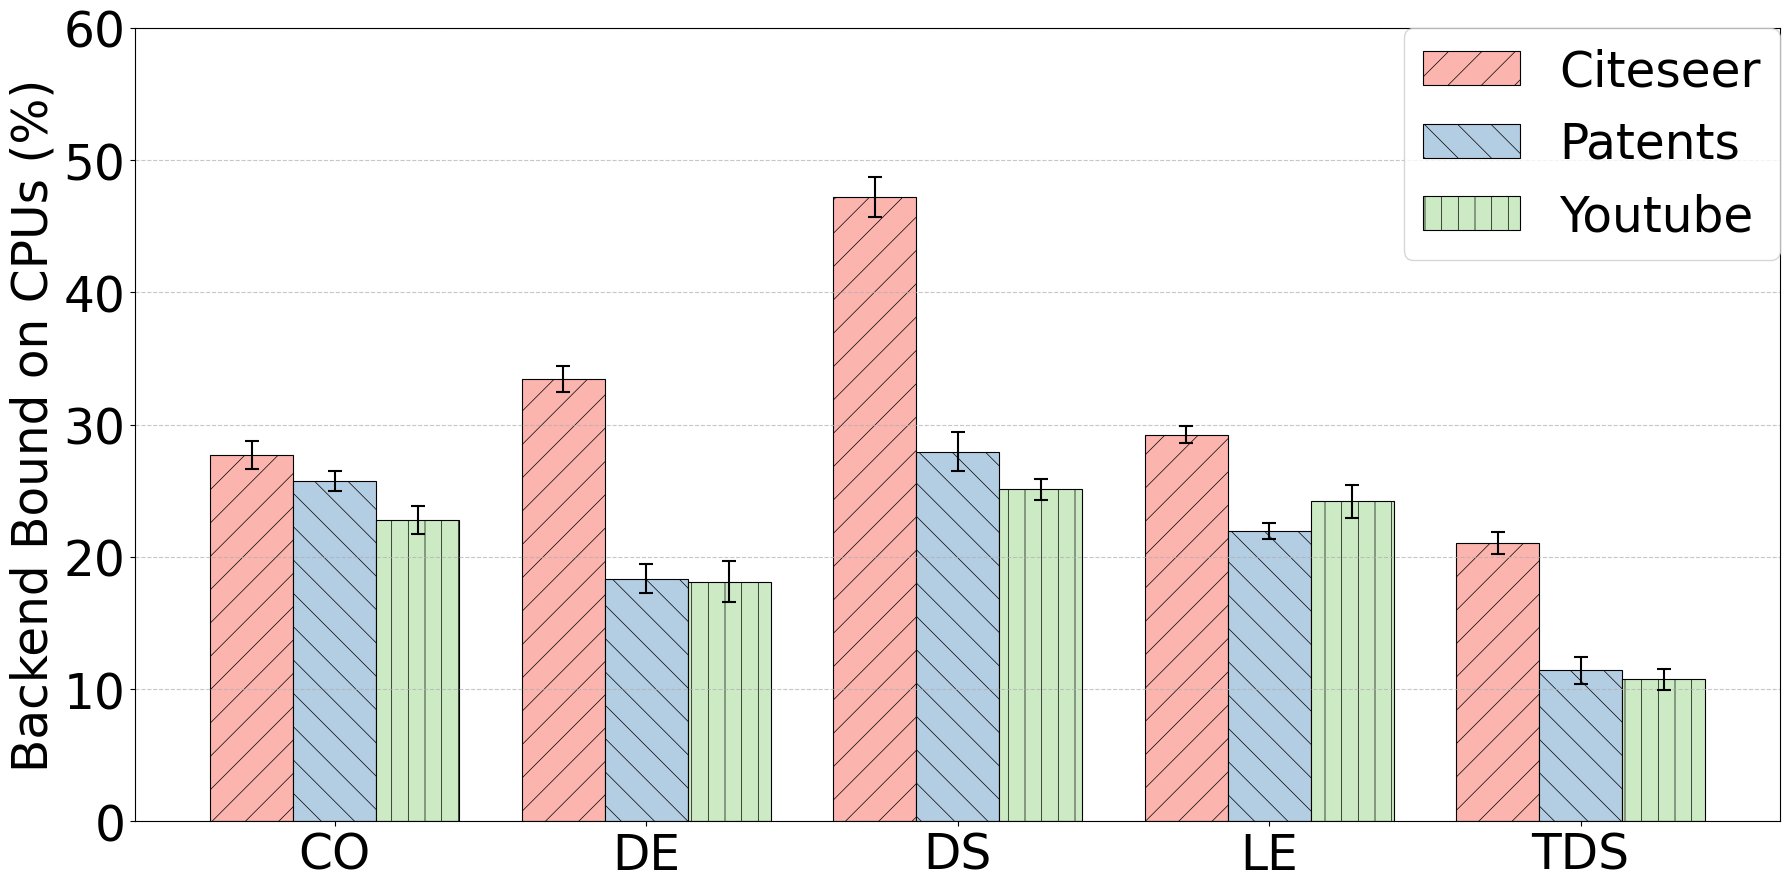

In [32]:
grouping_columns = ['obj_function']
plot_average_by_group_and_initial_solutions(df, grouping_columns, 'bebound', 'bebound_confidence_interval', 'Backend Bound on CPUs (%)', 'TMA Analysis Backend Bound')

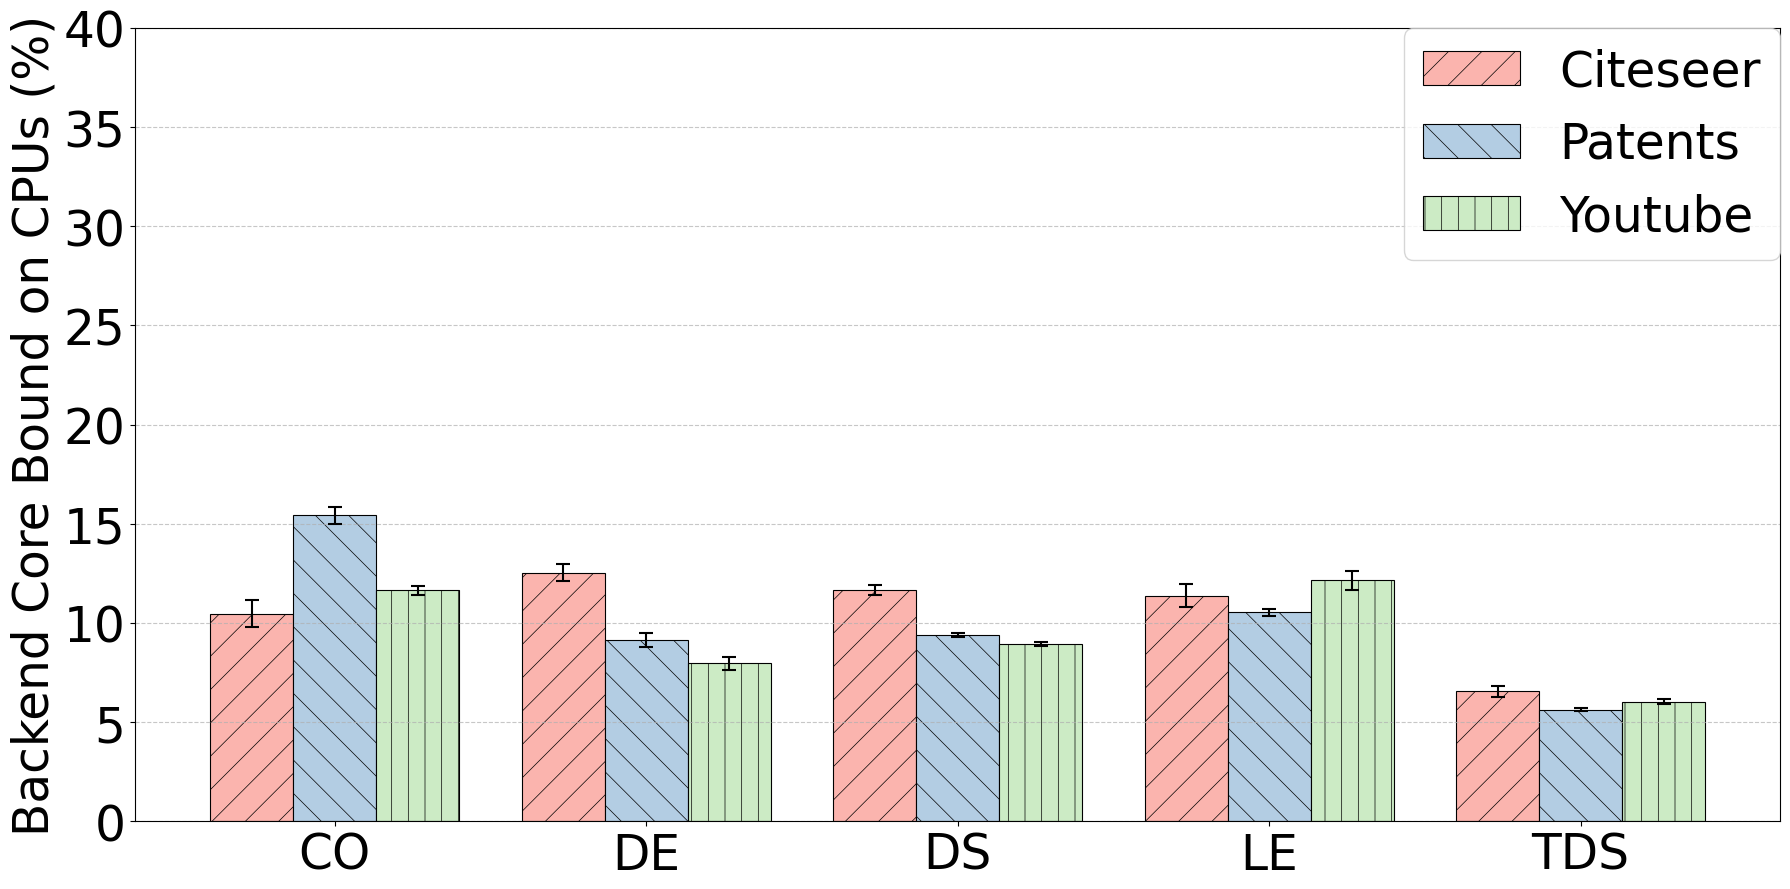

In [39]:
grouping_columns = ['obj_function']
plot_average_by_group_and_initial_solutions(df, grouping_columns, 'core_bound', 'core_bound_confidence_interval', 'Backend Core Bound on CPUs (%)', 'TMA Analysis Backend Core Bound', yrange=range(0, 41, 5))

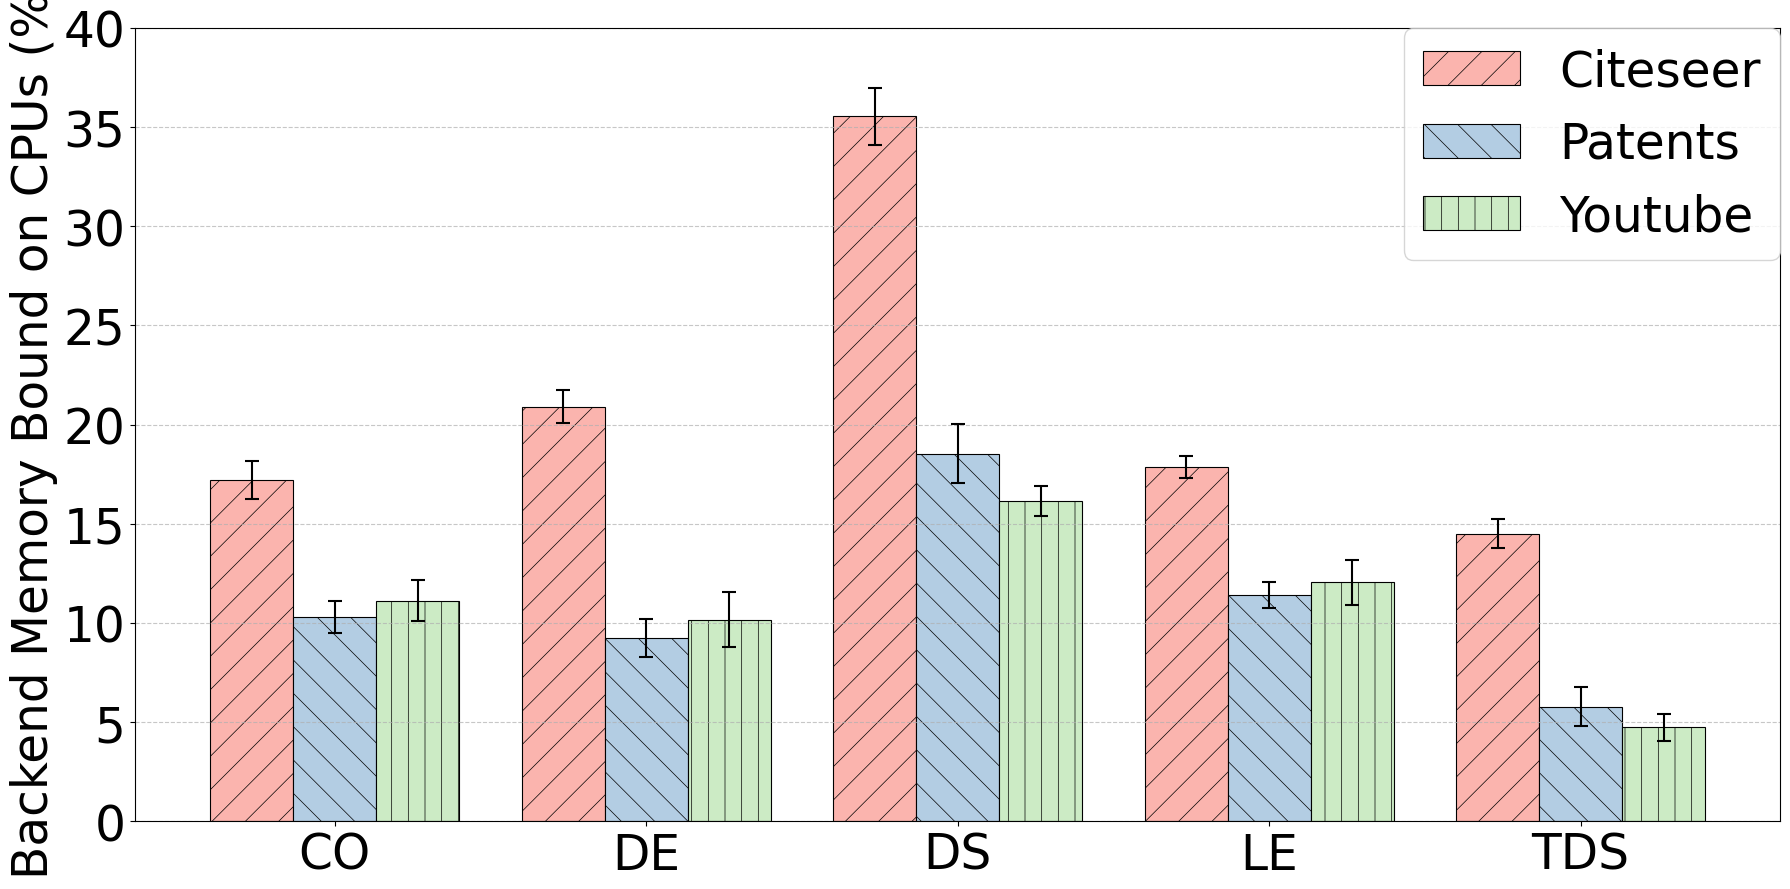

In [40]:
grouping_columns = ['obj_function']
plot_average_by_group_and_initial_solutions(df, grouping_columns, 'mem_bound', 'mem_bound_confidence_interval', 'Backend Memory Bound on CPUs (%)', 'TMA Analysis Backend Memory Bound', yrange=range(0, 41, 5))